## A PROJECT ON DATA ANALYSIS AND VISUALIZATION OF FOOTBALL MATCHES

# Importing Required Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#  Loading the Dataset on 'goalscorers'

In [ ]:
df = pd.read_csv("goalscorers.csv")
df.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False


# Understanding the Data

# The dataset contains information about football matches including teams, players, and goal details. It includes features like date, team names, scorer, minute of goal, and penalty information. The dataset consists of multiple rows and columns with both categorical and numerical data.

In [ ]:
df.columns

Index(['date', 'home_team', 'away_team', 'team', 'scorer', 'minute',
       'own_goal', 'penalty'],
      dtype='object')

In [ ]:
df.shape

(44362, 8)

In [ ]:
df.dtypes

date          object
home_team     object
away_team     object
team          object
scorer        object
minute       float64
own_goal        bool
penalty         bool
dtype: object

# Data Cleaning on 'Date' column

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df.dtypes

date         datetime64[ns]
home_team            object
away_team            object
team                 object
scorer               object
minute              float64
own_goal               bool
penalty                bool
dtype: object

# Feature Engineering ( Creating Year column )

In [ ]:
df['year']= df['date'].dt.year

In [ ]:
df.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty,year
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False,1916
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False,1916
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False,1916
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False,1916
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False,1916


#  Checking Missing Values

In [ ]:
df.isnull().sum()

date           0
home_team      0
away_team      0
team           0
scorer        49
minute       259
own_goal       0
penalty        0
year           0
dtype: int64

# Handling the Null Values by dropping

In [ ]:
df =df.dropna()

In [ ]:
df.isnull().sum()

date         0
home_team    0
away_team    0
team         0
scorer       0
minute       0
own_goal     0
penalty      0
year         0
dtype: int64

# Checking the duplicates

In [ ]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
44357    False
44358    False
44359    False
44360    False
44361    False
Length: 44102, dtype: bool

# Understaning other properties of dataframe

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44102 entries, 0 to 44361
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       44102 non-null  datetime64[ns]
 1   home_team  44102 non-null  object        
 2   away_team  44102 non-null  object        
 3   team       44102 non-null  object        
 4   scorer     44102 non-null  object        
 5   minute     44102 non-null  float64       
 6   own_goal   44102 non-null  bool          
 7   penalty    44102 non-null  bool          
 8   year       44102 non-null  int32         
dtypes: bool(2), datetime64[ns](1), float64(1), int32(1), object(4)
memory usage: 2.6+ MB


# The "describe" property gives an over view on "numerical columns" only

In [ ]:
df.describe()

,date,minute,year
count,44102,44102.000000,44102.000000
mean,1997-07-11 02:13:24.861457536,50.012652,1996.982223
min,1916-07-02 00:00:00,1.000000,1916.000000
25%,1986-06-29 00:00:00,28.000000,1986.000000
50%,2002-06-15 00:00:00,51.000000,2002.000000
75%,2013-10-11 00:00:00,73.000000,2013.000000
max,2024-07-14 00:00:00,122.000000,2024.000000
std,NaN,26.358310,21.723660


# The below property is to describe numerical as well as categorical columns

In [ ]:
df.describe(include = 'all')

,date,home_team,away_team,team,scorer,minute,own_goal,penalty,year
count,44102,44102,44102,44102,44102,44102.000000,44102,44102,44102.000000
unique,NaN,220,220,220,14248,NaN,2,2,NaN
top,NaN,Brazil,Uruguay,Brazil,Cristiano Ronaldo,NaN,False,False,NaN
freq,NaN,1023,787,1051,108,NaN,43281,41142,NaN
mean,1997-07-11 02:13:24.861457536,NaN,NaN,NaN,NaN,50.012652,NaN,NaN,1996.982223
min,1916-07-02 00:00:00,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,1916.000000
25%,1986-06-29 00:00:00,NaN,NaN,NaN,NaN,28.000000,NaN,NaN,1986.000000
50%,2002-06-15 00:00:00,NaN,NaN,NaN,NaN,51.000000,NaN,NaN,2002.000000
75%,2013-10-11 00:00:00,NaN,NaN,NaN,NaN,73.000000,NaN,NaN,2013.000000
max,2024-07-14 00:00:00,NaN,NaN,NaN,NaN,122.000000,NaN,NaN,2024.000000


# Exploratory Data Analysis

This project performs Exploratory Data Analysis (EDA) on a football dataset(goalscorers) to evaluate patterns
in goal scoring, team performance, and match trends.

#  UNIVARIATE ANALYSIS - Analyzing a single column at a time .

# 1. Goal Timing - Histogram ( to check the frequency distribution)

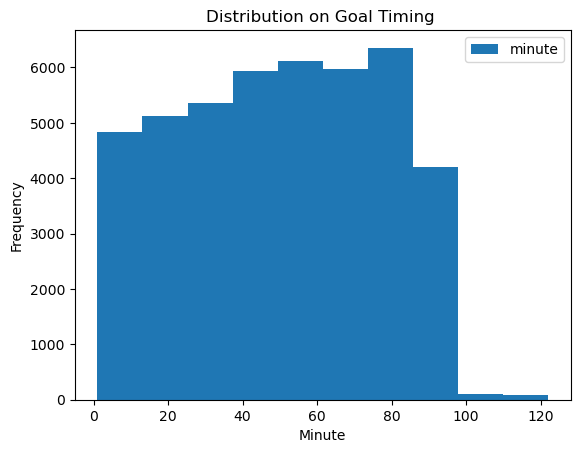

In [ ]:
df.plot(y='minute', kind='hist')
plt.title("Distribution on Goal Timing ")
plt.xlabel("Minute")
plt.ylabel("Frequency")
plt.show()

# Goal Timing - Box Plot ( to detect the outliers )

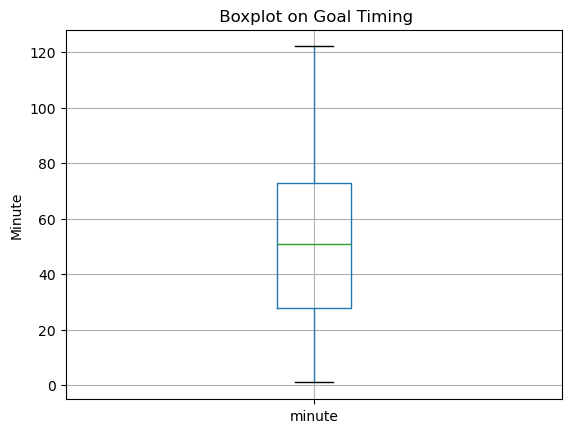

In [ ]:
df.boxplot(column='minute')
plt.title(" Boxplot on Goal Timing")
plt.ylabel("Minute")
plt.show()

 # BIVARIATE ANALYSIS - Analyzing two columns at a time .

# 1. Year vs Goal Minute - Scatter chart ( relates two numerical columns )

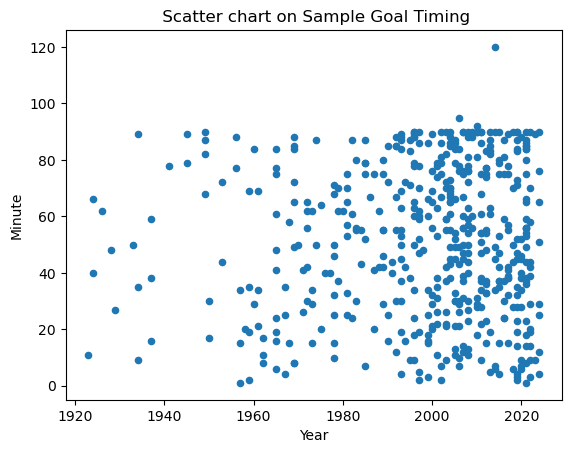

In [ ]:
df_sample = df.sample(500)

df_sample.plot(x='year', y='minute', kind='scatter')
plt.title(" Scatter chart on Sample Goal Timing")
plt.xlabel("Year")
plt.ylabel("Minute")
plt.show()

# 2. Year vs Goal Minute - Line chart ( for trends & patterns )

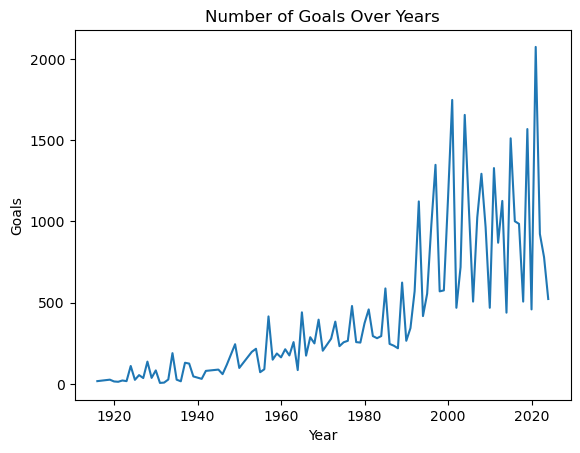

In [ ]:
df['year'].value_counts().sort_index().plot()
plt.title("Number of Goals Over Years")
plt.xlabel("Year")
plt.ylabel("Goals")
plt.show()

# 3. Top Teams vs Goals - Bar Chart ( comparison)

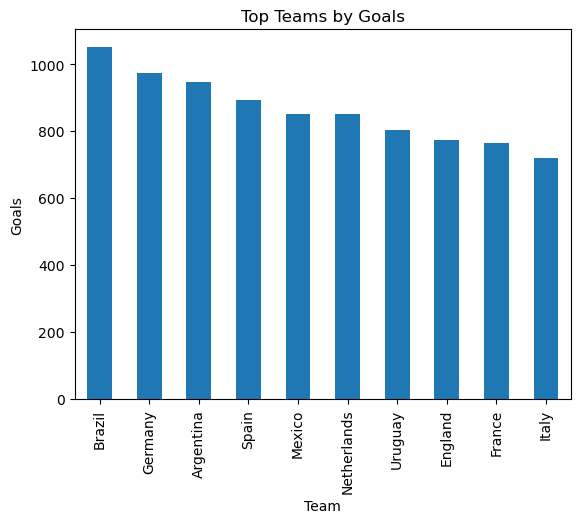

In [ ]:
df['team'].value_counts().head(10).plot(kind='bar')
plt.title("Top Teams by Goals")
plt.xlabel("Team")
plt.ylabel("Goals")
plt.show()

##  KEY INSIGHTS :

- Brazil holds the highest goalcount followed by Germany , Argentina and so on showing the strong team performance.
- Most of the goals are scored during the middle phase of the match having fewer goals in the beginning and ending of the match .
- There is an increase in total goals over years especially after 2000.